# 03 — 진단·decision gate 해부: 이 추정치를 믿어도 되는가

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 계산하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 이다. 정본 수치는 [`docs/LEDGER.md`](../docs/LEDGER.md) 뿐이며, 기존 결과를
> 인용할 때는 행 id 를 병기한다. 규약: [`notebooks/README.md`](README.md).

02권까지의 질문이 "V(π_e) 를 어떻게 추정하나"였다면, 이 권의 질문은 **"그 추정치를 믿어도
되는가"**다. OPE 의 실무 종착점은 점추정이 아니라 **배포 결정**이고, 결정에는 신뢰 판정이
선행해야 한다. [`src/ope/diagnostics.py`](../src/ope/diagnostics.py) 는 **로그만으로(참값
없이) 계산 가능한** 진단 3종 — ESS · max importance weight · support proxy — 과 3-way
**decision gate** (trust / distrust / ab_fallback) 를 구현한다. 이 노트북은:

1. 세 진단의 계산 과정을 numpy 로 한 단계씩 열고 `compute_diagnostics` 와 대조(assert)한다.
2. `decision_gate` 가 판정하는 순간 — 어느 조건이 발동해 어느 arm 으로 가는가 — 를 트레이스한다.
3. 이 장치가 **원리적으로 못 보는 것**(unobserved confounding)을 미니 재현으로 전시한다.

**정직성 주의.** gate 의 규칙·임계값(`PROVISIONAL_THRESHOLDS`)은 **본 레포의 제안**
(folklore 관행의 체계화 시도)이며 **문헌 표준이 아니다**. 값은 M1 에서 사전등록됐고,
축 08 은 그 값을 튜닝 없이 그대로 평가만 한다 — 예보력의 정본은 LEDGER `m2-08-forecast`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import CONTEXT_GRAY, ESTIMATOR_COLORS, ORACLE_COLOR, apply_style  # noqa: E402

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt  # noqa: E402

from ope.dgp import (DGPConfig, _support_mask, make_synthetic_bandit_data,  # noqa: E402
                     true_policy_value)
from ope.diagnostics import (PROVISIONAL_THRESHOLDS, DiagnosticsReport,  # noqa: E402
                             compute_diagnostics, decision_gate)
from ope.estimators import estimate_ips  # noqa: E402

C_HEALTHY = ESTIMATOR_COLORS["dm"]    # blue — healthy 무대
C_HARSH = ESTIMATOR_COLORS["ips"]     # orange — harsh 무대 (bias 패널의 IPS entity 색과 동일 계열)
C_CONF = ESTIMATOR_COLORS["dros"]     # violet — confounded 무대
DIAG_COLOR = "#3f3e39"                # 진단 곡선 — estimator 팔레트 밖 중립색 (축 09 관례)
THRESH_COLOR = "#a33b3b"              # [제안] 임계선 전용색 (축 09 관례)
GRAY = "#9a9a9a"

## A. 세 로그 무대 — healthy · harsh · confounded

같은 환경(`struct_seed=7`)·같은 평가 정책(β_eval=3) 아래 **로깅만 다른** 세 로그를 세운다
(base 는 `experiments/_common.BASE_M2` 와 동일값 — n=10,000, K=10):

- **healthy** — β_log=1: 로깅이 충분히 탐색적, overlap 양호.
- **harsh** — β_log=8: 로깅이 확신에 차 일부 행동을 거의 안 뽑는다 — weight 꼬리 스트레스.
- **confounded** — β_log=1, γ=1.5: 미관측 U 가 로깅 선택과 보상에 동시 개입.
  **기록된 propensity(`pscore_logged`)와 진짜 propensity(`pscore_true`)가 다른** 로그다
  ([`src/ope/dgp.py`](../src/ope/dgp.py) 의 축 09 장치).

In [2]:
BASE = DGPConfig(n=10_000, n_actions=10, dim_context=5, beta_log=1.0, beta_eval=3.0,
                 support_deficiency=0.0, reward_noise=0.5, confounding_strength=0.0,
                 seed=0, struct_seed=7)
STAGES = {
    "healthy": BASE,
    "harsh": BASE._replace(beta_log=8.0),
    "confounded": BASE._replace(confounding_strength=1.5),
}
logs = {name: make_synthetic_bandit_data(cfg) for name, cfg in STAGES.items()}
V_TRUE = true_policy_value(BASE)  # 구조·β_eval 에만 의존 — γ·β_log 와 무관 (dgp.py 의 정리)

rows = []
for name, cfg in STAGES.items():
    d = logs[name]
    rows.append({
        "log": name, "beta_log": cfg.beta_log, "gamma": cfg.confounding_strength,
        "n": cfg.n, "K": cfg.n_actions, "mean_reward": d.reward.mean(),
        "pscore_min": d.pscore_logged.min(), "pscore_max": d.pscore_logged.max(),
        "logged=true pscore": bool(np.allclose(d.pscore_logged, d.pscore_true)),
    })
stage_summary = pd.DataFrame(rows).set_index("log")
print(f"V(pi_e) ground truth = {V_TRUE:.4f}   (세 무대 공통 — dgp.py 의 γ-불변 정리)")
display(stage_summary.style.format({"mean_reward": "{:.3f}",
                                    "pscore_min": "{:.2e}", "pscore_max": "{:.3f}"}))

V(pi_e) ground truth = 0.7154   (세 무대 공통 — dgp.py 의 γ-불변 정리)


,beta_log,gamma,n,K,mean_reward,pscore_min,pscore_max,logged=true pscore
log,,,,,,,,
healthy,1.000000,0.000000,10000,10,0.595,4.69e-02,0.201,True
harsh,8.000000,0.000000,10000,10,0.839,3.05e-04,0.986,True
confounded,1.000000,1.500000,10000,10,0.591,4.69e-02,0.199,False


마지막 열이 이 권의 복선이다: confounded 로그는 **겉보기 요약으로는 healthy 와 거의 구별되지
않고**, 다른 것은 estimator 가 볼 수 없는 `pscore_true` 뿐이다. 진단이 이 차이를 잡아낼 수
있는지는 F 절에서 돌아온다. 먼저 진단 3종을 하나씩 연다.

## B. ESS 해부 — "유효 표본 몇 개짜리 추정인가"

importance weight $w_i = \pi_e(a_i|x_i)/\pi_0(a_i|x_i)$ 로 재가중된 표본의 effective sample
size:

$$\mathrm{ESS} \;=\; \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}$$

양끝 직관 — 모든 $w_i$ 가 같으면 ESS $=n$ (재가중이 공짜), 한 $w_i$ 가 지배하면 ESS $\to 1$
(사실상 표본 하나짜리 추정). `compute_diagnostics` 는 규모 불변량 **ESS/n** (`ess_ratio`)
으로 보고한다. 분자·분모를 numpy 로 직접 밟아 모듈 구현과 대조한다.

In [3]:
d = logs["healthy"]
n = len(d.action)
w = d.pi_e_dist[np.arange(n), d.action] / d.pscore_logged  # w_i = π_e(a_i|x_i)/π_0(a_i|x_i)

numerator = w.sum() ** 2      # (Σw)²
denominator = (w**2).sum()    # Σw²
ess_manual = numerator / denominator
print("healthy 로그, 단계별 계산:")
print(f"  Σw = {w.sum():,.1f}    (Σw)² = {numerator:,.1f}    Σw² = {denominator:,.1f}")
print(f"  ESS = (Σw)²/Σw² = {ess_manual:,.1f}    ESS/n = {ess_manual / n:.4f}")
print()

diags = {}
for name, dd in logs.items():
    nn = len(dd.action)
    ww = dd.pi_e_dist[np.arange(nn), dd.action] / dd.pscore_logged
    manual = ww.sum() ** 2 / (ww**2).sum()
    rep = compute_diagnostics(dd.pscore_logged, dd.action, dd.pi_e_dist)
    assert np.isclose(rep.ess, manual), name           # 수동 계산 = 모듈 계산
    assert np.isclose(rep.ess_ratio, manual / nn), name
    assert np.isclose(rep.max_weight, ww.max()), name
    diags[name] = rep
    print(f"{name:11s} ESS/n = {rep.ess_ratio:.4f}   max w = {rep.max_weight:6.2f}   "
          f"p99(w) = {rep.weight_tail_p99:.2f}   — compute_diagnostics 와 일치 (assert 통과)")

healthy 로그, 단계별 계산:
  Σw = 10,045.1    (Σw)² = 100,903,928.4    Σw² = 12,254.7
  ESS = (Σw)²/Σw² = 8,233.9    ESS/n = 0.8234

healthy     ESS/n = 0.8234   max w =   2.65   p99(w) = 2.08   — compute_diagnostics 와 일치 (assert 통과)
harsh       ESS/n = 0.3172   max w =  63.27   p99(w) = 5.38   — compute_diagnostics 와 일치 (assert 통과)
confounded  ESS/n = 0.8234   max w =   2.72   p99(w) = 2.05   — compute_diagnostics 와 일치 (assert 통과)


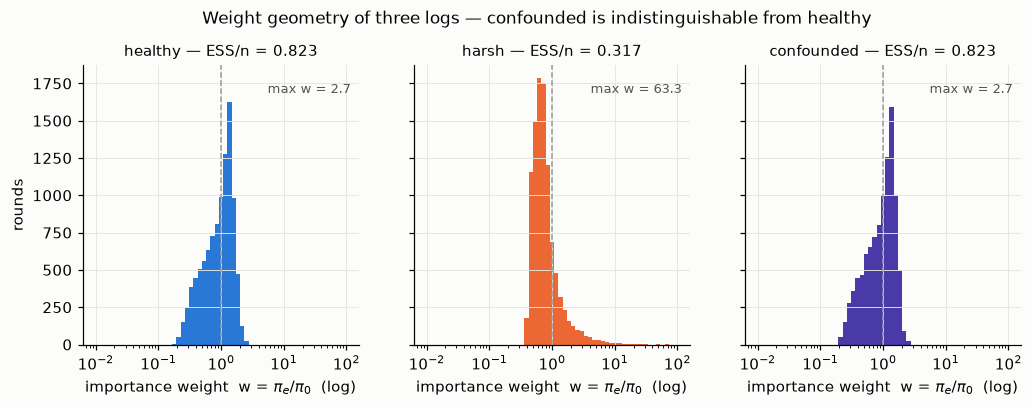

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), sharey=True)
bins = np.logspace(-2, 2, 60)
for ax, (name, color) in zip(axes, (("healthy", C_HEALTHY), ("harsh", C_HARSH),
                                    ("confounded", C_CONF))):
    dd = logs[name]
    ww = dd.pi_e_dist[np.arange(len(dd.action)), dd.action] / dd.pscore_logged
    ax.hist(ww, bins=bins, color=color)
    ax.set_xscale("log")
    ax.axvline(1.0, color=GRAY, lw=1, ls="--")
    ax.set_title(f"{name} — ESS/n = {diags[name].ess_ratio:.3f}", fontsize=10)
    ax.annotate(f"max w = {diags[name].max_weight:.1f}", xy=(0.97, 0.90),
                xycoords="axes fraction", ha="right", fontsize=8.5, color="#55544e")
    ax.set_xlabel("importance weight  w = $\\pi_e/\\pi_0$  (log)")
axes[0].set_ylabel("rounds")
fig.suptitle("Weight geometry of three logs — confounded is indistinguishable from healthy",
             y=1.03, fontsize=11)
plt.show()

healthy 와 confounded 의 weight 분포는 사실상 겹친다(ESS/n ≈ 0.82) — harsh 만 꼬리가 자라
ESS/n ≈ 0.32 로 내려간다. 여기서 문장 하나를 기억해 두자: **진단은 weight 의 함수이고,
weight 는 기록 propensity 의 함수다.** 이 당연한 문장이 F 절의 blind spot 을 만든다.

## C. max-weight — 꼬리 한 줄이 쥐는 지분

$\max_i w_i$ 는 "최악의 한 줄"이 추정에 행사할 수 있는 지렛대다. IPS 추정치는
$\hat V = \tfrac{1}{n}\sum_i w_i r_i$ 이므로 row $i$ 의 기여 지분은 $w_i r_i / \sum_j w_j r_j$.
harsh 로그에서 weight 상위 row 들의 지분과, 세 로그의 weight 집중도를 본다.

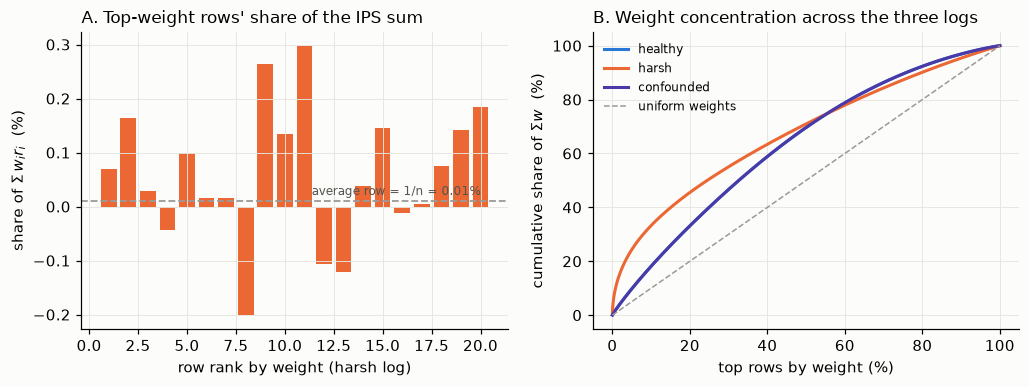

harsh top-1 row: w = 63.3, 기여 지분 = 0.070% (평균 row 의 7.0배)
healthy     상위 1% row 가 쥔 Σw 지분 = 2.2%
harsh       상위 1% row 가 쥔 Σw 지분 = 11.1%
confounded  상위 1% row 가 쥔 Σw 지분 = 2.2%


In [5]:
d_h = logs["harsh"]
res_h = estimate_ips(d_h.reward, d_h.action, d_h.pscore_logged, d_h.pi_e_dist)
w_h = res_h.weights
contrib = w_h * d_h.reward          # row 별 기여 — V̂_IPS = mean(w·r) = Σ contrib / n
share = contrib / contrib.sum()
top_by_w = np.argsort(-w_h)[:20]    # weight 상위 20 row

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 3.5))
ax_l.bar(np.arange(1, 21), 100 * share[top_by_w], color=C_HARSH)
ax_l.axhline(100 / len(w_h), color=GRAY, lw=1.2, ls="--")
ax_l.annotate("average row = 1/n = 0.01%", xy=(20, 100 / len(w_h)), xytext=(0, 4),
              textcoords="offset points", ha="right", fontsize=8, color="#55544e")
ax_l.set_xlabel("row rank by weight (harsh log)")
ax_l.set_ylabel("share of $\\Sigma\\, w_i r_i$  (%)")
ax_l.set_title("A. Top-weight rows' share of the IPS sum", loc="left")

for name, color in (("healthy", C_HEALTHY), ("harsh", C_HARSH), ("confounded", C_CONF)):
    dd = logs[name]
    ww = np.sort(dd.pi_e_dist[np.arange(len(dd.action)), dd.action] / dd.pscore_logged)[::-1]
    frac = np.arange(1, len(ww) + 1) / len(ww)
    ax_r.plot(100 * frac, 100 * ww.cumsum() / ww.sum(), color=color, lw=2, label=name)
ax_r.plot([0, 100], [0, 100], color=GRAY, lw=1, ls="--", label="uniform weights")
ax_r.set_xlabel("top rows by weight (%)")
ax_r.set_ylabel("cumulative share of $\\Sigma w$  (%)")
ax_r.set_title("B. Weight concentration across the three logs", loc="left")
ax_r.legend(fontsize=8)
plt.show()

i_max = int(np.argmax(w_h))
print(f"harsh top-1 row: w = {w_h[i_max]:.1f}, 기여 지분 = {100 * share[i_max]:.3f}% "
      f"(평균 row 의 {share[i_max] * len(w_h):.1f}배)")
for name in logs:
    dd = logs[name]
    ww = np.sort(dd.pi_e_dist[np.arange(len(dd.action)), dd.action] / dd.pscore_logged)[::-1]
    k = len(ww) // 100
    print(f"{name:11s} 상위 1% row 가 쥔 Σw 지분 = {100 * ww[:k].sum() / ww.sum():.1f}%")

합성 harsh 무대(연속 보상·n=10,000)에서는 상위 1% row 가 Σw 의 ~11% 를 쥔다(healthy 는 ~2%)
— 아직 "완만한" 집중이다. 이 지렛대는 **보상이 희소할수록 파괴적**이 된다: 실로그 OBD 에서는
클릭 한 개가 IPS 추정의 **0.33** 을 쥐었다(top1 클릭 기여 0.3300, max w 277.78 — LEDGER
`m3-12-gate-demo`). max-weight 진단이 cap(아래 E 절) 하나로 지렛대 자체를 감시하는 이유다.

## D. support proxy — 전역 부재만 보이는 진단

`support_deficiency` proxy = 전역 평균 $\bar\pi_e$ 질량 중 **로그에 한 번도 등장하지 않은
액션**의 비율. 로그만으로 계산 가능하다는 것이 미덕이고, "전역"이라는 것이 한계다.
신호가 나는 경우와 원리적으로 안 나는 경우를 나란히 세운다.

In [6]:
# (1) 신호 사례 — 구성(constructed): healthy 로그에서 action 9 의 행을 통째로 제거해
#     "전역 부재 액션"을 인위로 만든다.
d_heal = logs["healthy"]
DROP_ACTION = 9
keep = d_heal.action != DROP_ACTION
rep_hole = compute_diagnostics(d_heal.pscore_logged[keep], d_heal.action[keep],
                               d_heal.pi_e_dist[keep])
hole_true_mass = float(d_heal.pi_e_dist[keep][:, DROP_ACTION].mean())
print(f"global-hole(구성): action {DROP_ACTION} 의 행 {int((~keep).sum())}개 제거 → "
      f"proxy = {rep_hole.support_deficiency:.4f} "
      f"(임계 {PROVISIONAL_THRESHOLDS.support_deficiency_max} 초과 — 발화)")

# (2) 무신호 사례 — 축 04 방식의 구조적 결핍: 컨텍스트별 하위-q ⌊δK⌋개 액션의 로깅 지지 제거.
#     어떤 액션도 "전역에서 0회"는 아니므로 proxy 는 원리적으로 침묵한다.
DELTA = 0.3
d_def = make_synthetic_bandit_data(BASE._replace(support_deficiency=DELTA))
rep_def = compute_diagnostics(d_def.pscore_logged, d_def.action, d_def.pi_e_dist)
assert rep_def.support_deficiency == 0.0  # 전면 blind — 축 04 와 동일 기제
# oracle 참값: DGP 자신의 mask 규칙을 읽기 전용 재사용 (축 04 패턴 — 재구현 불일치 위험 제거)
unsupported = ~_support_mask(d_def.q_true, DELTA)
true_mass = float((d_def.pi_e_dist * unsupported).sum(axis=1).mean())
print(f"structural δ={DELTA}(축 04 방식): proxy = {rep_def.support_deficiency:.4f}  vs  "
      f"참 미지지 π_e 질량(oracle) = {true_mass:.4f}  — proxy 무신호 (assert 통과)")

global-hole(구성): action 9 의 행 939개 제거 → proxy = 0.0896 (임계 0.02 초과 — 발화)
structural δ=0.3(축 04 방식): proxy = 0.0000  vs  참 미지지 π_e 질량(oracle) = 0.0920  — proxy 무신호 (assert 통과)


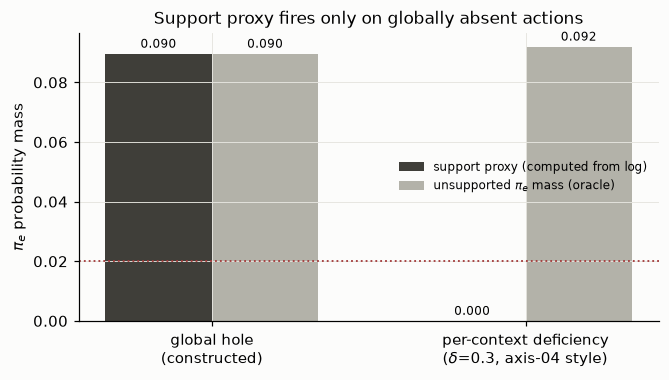

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
xs = np.arange(2)
proxy_vals = [rep_hole.support_deficiency, rep_def.support_deficiency]
oracle_vals = [hole_true_mass, true_mass]
b1 = ax.bar(xs - 0.17, proxy_vals, width=0.34, color=DIAG_COLOR,
            label="support proxy (computed from log)")
b2 = ax.bar(xs + 0.17, oracle_vals, width=0.34, color=CONTEXT_GRAY,
            label="unsupported $\\pi_e$ mass (oracle)")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax.axhline(PROVISIONAL_THRESHOLDS.support_deficiency_max, color=THRESH_COLOR, ls=":", lw=1.2)
ax.annotate("gate threshold 0.02 (proposed in this repo — not a literature standard)",
            xy=(-0.45, PROVISIONAL_THRESHOLDS.support_deficiency_max), xytext=(0, 3),
            textcoords="offset points", fontsize=7.5, color=THRESH_COLOR)
ax.set_xticks(xs)
ax.set_xticklabels(["global hole\n(constructed)",
                    f"per-context deficiency\n($\\delta$={DELTA}, axis-04 style)"])
ax.set_ylabel("$\\pi_e$ probability mass")
ax.set_title("Support proxy fires only on globally absent actions", fontsize=11)
ax.legend(fontsize=8)
plt.show()

proxy 는 왼쪽(전역 구멍)처럼 액션이 로그에서 통째로 비어야만 발화하고, 그때는 oracle 과
일치한다 — proxy 의 정의역이 정확히 그 경우다. 오른쪽처럼 결핍이 **컨텍스트-국소적**이면
참 미지지 질량이 커져도 proxy 는 0 에 못박힌다. 정본 실증은 축 04: 전 δ 에서 proxy = 0.00000
vs oracle 참 미지지 질량 0.0227(δ=0.1) → 0.1434(δ=0.4) (LEDGER `m2-04-proxy-blind`).
축 08 의 pooled 평가에서 **support arm 이 한 번도 발화하지 않은** 이유이기도 하다
(`m2-08-forecast` 행의 "support arm 발화 0회" — 퇴화 정직 기록).

## E. decision_gate — 판정의 순간

진단 3종을 하나의 3-way 판정으로 접는 것이 `decision_gate` 다. 임계값부터 —
**[제안 — 문헌 표준 아님]**: M1 에서 folklore 관행으로부터 사전등록된 값이고, 축 08 은 이
값을 튜닝 없이 그대로 평가만 한다(순환 회피 설계).

In [8]:
thr = PROVISIONAL_THRESHOLDS
thr_table = pd.DataFrame([
    {"threshold": "ess_ratio_hard", "value": thr.ess_ratio_hard,
     "violation arm": "ab_fallback (즉시 반환 — 추정 자체 불성립)"},
    {"threshold": "ess_ratio_soft", "value": thr.ess_ratio_soft, "violation arm": "distrust"},
    {"threshold": "max_weight_cap", "value": thr.max_weight_cap, "violation arm": "distrust"},
    {"threshold": "support_deficiency_max", "value": thr.support_deficiency_max,
     "violation arm": "distrust"},
]).set_index("threshold")
print("PROVISIONAL_THRESHOLDS — [제안] 본 레포의 사전등록 값 (문헌 표준 아님):")
display(thr_table)

PROVISIONAL_THRESHOLDS — [제안] 본 레포의 사전등록 값 (문헌 표준 아님):


,value,violation arm
threshold,,
ess_ratio_hard,0.01,ab_fallback (즉시 반환 — 추정 자체 불성립)
ess_ratio_soft,0.10,distrust
max_weight_cap,100.00,distrust
support_deficiency_max,0.02,distrust


판정 경로는 세 단계다 (`decision_gate` 구현 순서 그대로):

1. `ess_ratio < ess_ratio_hard` → **ab_fallback** 을 *즉시 반환* — 무엇을 믿을지 이전에
   추정 자체가 불성립. 다른 조건은 보지도 않는다(단락, short-circuit).
2. support proxy · soft ESS · max-weight 위반을 *누적* — 하나라도 있으면 **distrust**
   (사유 전부 기록).
3. 아무것도 발동하지 않으면 **trust**.

세 무대 로그와, 판정 경로를 마저 보여줄 시연 행들을 게이트에 통과시킨다.

In [9]:
def trace_gate(name: str, report: DiagnosticsReport) -> dict:
    verdict = decision_gate(report, PROVISIONAL_THRESHOLDS)
    return {"log": name, "ess_ratio": report.ess_ratio, "max_weight": report.max_weight,
            "support_proxy": report.support_deficiency, "decision": verdict.decision,
            "fired conditions": " | ".join(verdict.reasons) if verdict.reasons
                                else "(none — all checks passed)"}

rows = [trace_gate(name, diags[name]) for name in logs]
d12 = make_synthetic_bandit_data(BASE._replace(beta_log=12.0))
rows.append(trace_gate("harsh-extreme (beta_log=12, 시연)",
                       compute_diagnostics(d12.pscore_logged, d12.action, d12.pi_e_dist)))
rows.append(trace_gate("global-hole (구성 사례, §D)", rep_hole))
d_conf = logs["confounded"]
rows.append(trace_gate("confounded + true pscore (oracle)",
                       compute_diagnostics(d_conf.pscore_true, d_conf.action,
                                           d_conf.pi_e_dist)))
gate_trace = pd.DataFrame(rows).set_index("log")
display(gate_trace.style.format({"ess_ratio": "{:.4f}", "max_weight": "{:.2f}",
                                 "support_proxy": "{:.4f}"}))

,ess_ratio,max_weight,support_proxy,decision,fired conditions
log,,,,,
healthy,0.8234,2.65,0.0000,trust,(none — all checks passed)
harsh,0.3172,63.27,0.0000,trust,(none — all checks passed)
confounded,0.8234,2.72,0.0000,trust,(none — all checks passed)
"harsh-extreme (beta_log=12, 시연)",0.0398,367.55,0.0000,distrust,ess_ratio 0.0398 < soft floor 0.1 | max_weight 367.55 > cap 100.0
"global-hole (구성 사례, §D)",0.8260,2.65,0.0896,distrust,support proxy 0.0896 > 0.02
confounded + true pscore (oracle),0.0889,194.59,0.0000,distrust,ess_ratio 0.0889 < soft floor 0.1 | max_weight 194.59 > cap 100.0


In [10]:
# 경로 ①(hard floor)의 단락 시연 — 축 08 과 같은 방식으로 report 를 직접 구성해 게이트만 호출.
degenerate = DiagnosticsReport(ess=50.0, ess_ratio=0.005, max_weight=900.0,
                               weight_tail_p99=np.nan, support_deficiency=0.5)
v = decision_gate(degenerate, PROVISIONAL_THRESHOLDS)
print(f"ess_ratio=0.005 (< hard 0.01) → decision = {v.decision}")
print(f"reasons = {v.reasons}")
print("→ max_weight·support 위반이 공존해도 기록된 사유는 hard floor 하나뿐 — "
     "경로 ①이 ②를 보기 전에 반환한다.")

ess_ratio=0.005 (< hard 0.01) → decision = ab_fallback
reasons = ('ess_ratio 0.0050 < hard floor 0.01',)
→ max_weight·support 위반이 공존해도 기록된 사유는 hard floor 하나뿐 — 경로 ①이 ②를 보기 전에 반환한다.


트레이스에서 읽을 것 세 가지:

- **세 무대 로그는 전부 trust 다.** harsh(ESS/n ≈ 0.32)조차 soft floor 0.10 위라 통과한다 —
  이 임계 아래로 내려가려면 β_log=12 급이 필요했고, 그 시연 행에서는 soft ESS 와 max-weight
  **두 사유가 동시에** 발동한다.
- **confounded 의 trust 가 이 권의 함정이다.** 같은 로그에 진짜 propensity(`pscore_true`)를
  주면 같은 게이트가 distrust 를 내린다(oracle 행) — 게이트 통과는 무결의 증명이 아니다.
- global-hole 행은 §D 의 support arm 이 실제로 distrust 를 만드는 유일한 경로를 보여준다.

이 게이트가 "쓸모 있는 예보"인가의 정본은 축 08 이다: 사전등록 임계값의 무튜닝 평가에서
대오차(상대오차 > 0.10) 비율이 **trust 4.6% vs distrust 14.1% vs ab_fallback 44.4%** 로
갈린다(축약 표기 — 정확 수치는 LEDGER `m2-08-forecast` 행 verbatim). 실데이터 판정 사례는
OBD small: **DISTRUST** (ess_ratio 0.0340 < soft 0.10 · max w 277.78 > cap 100 — LEDGER
`m3-12-gate-demo`).

## F. blind spot 미니 재현 — 진단은 기록을 믿는다

E 절의 함정을 스윕으로 편다. 메커니즘은 한 줄이다: **진단은 weight 만 보고, weight 는 기록
propensity 로 계산된다. 기록이 거짓이면 진단은 원리적으로 못 본다.** confounding(γ)은
로깅의 *실제* 행동선택을 왜곡하지만 *기록*(`pscore_logged`)은 배포 설정 그대로이므로,
로그에서 계산한 weight 기하는 γ 와 무관하게 태연하다 — bias 만 자란다.

γ ∈ {0, 0.5, 1, 1.5, 2} 스윕, S=10 seeds, n=10,000 — **탐색 지위** (정본은 축 09:
S=40 · n=30,000, LEDGER `m2-09-blindspot`).

In [11]:
GAMMAS = [0.0, 0.5, 1.0, 1.5, 2.0]
SWEEP_SEEDS = range(2000, 2010)  # S=10

recs = []
for gamma in GAMMAS:
    for seed in SWEEP_SEEDS:
        dd = make_synthetic_bandit_data(BASE._replace(confounding_strength=gamma, seed=seed))
        recs.append({
            "gamma": gamma, "seed": seed,
            "ess_logged": compute_diagnostics(dd.pscore_logged, dd.action,
                                              dd.pi_e_dist).ess_ratio,
            "ess_oracle": compute_diagnostics(dd.pscore_true, dd.action,
                                              dd.pi_e_dist).ess_ratio,
            "ips_logged": estimate_ips(dd.reward, dd.action, dd.pscore_logged,
                                       dd.pi_e_dist).value,
            "ips_oracle": estimate_ips(dd.reward, dd.action, dd.pscore_true,
                                       dd.pi_e_dist).value,
        })
sweep = pd.DataFrame(recs)

def _sem(s: pd.Series) -> float:
    return s.std(ddof=1) / np.sqrt(len(s))

g = sweep.groupby("gamma")
sw = pd.DataFrame({
    "ess_logged": g["ess_logged"].mean(),
    "ess_oracle": g["ess_oracle"].mean(),
    "bias_logged": g["ips_logged"].mean() - V_TRUE,
    "se_logged": g["ips_logged"].apply(_sem),
    "bias_oracle": g["ips_oracle"].mean() - V_TRUE,
    "se_oracle": g["ips_oracle"].apply(_sem),
}).reset_index()
display(sw.style.format("{:.4f}"))

,gamma,ess_logged,ess_oracle,bias_logged,se_logged,bias_oracle,se_oracle
0,0.0000,0.8226,0.8226,0.0008,0.0021,0.0008,0.0021
1,0.5000,0.8220,0.6273,-0.0071,0.0022,-0.0012,0.0027
2,1.0000,0.8225,0.2338,-0.0165,0.0022,0.0015,0.0076
3,1.5000,0.8221,0.1053,-0.0289,0.0023,0.0077,0.0240
4,2.0000,0.8214,0.0518,-0.0398,0.0030,-0.0710,0.0237


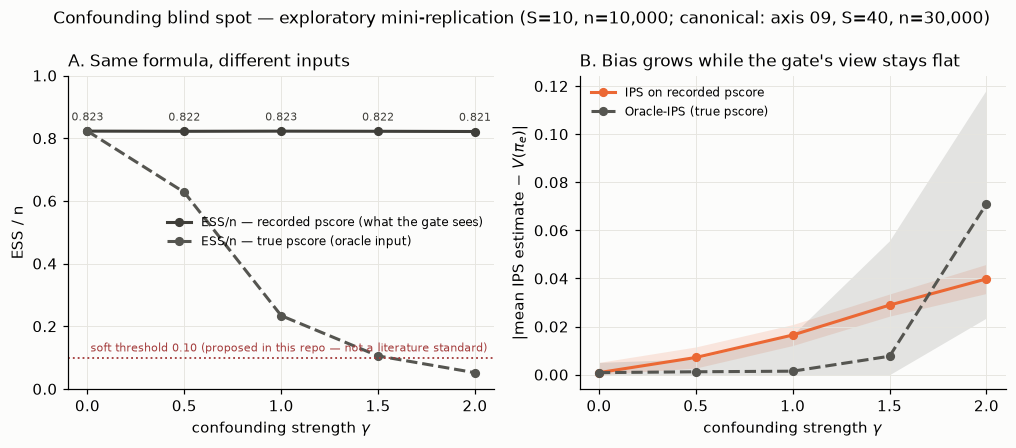

In [12]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 3.7))

# 패널 A — 게이트가 보는 것: 기록 pscore 기준 ESS/n (평평) vs 진짜 pscore 기준 (붕괴)
ax_a.plot(sw["gamma"], sw["ess_logged"], marker="o", color=DIAG_COLOR,
          label="ESS/n — recorded pscore (what the gate sees)")
ax_a.plot(sw["gamma"], sw["ess_oracle"], marker="o", ls="--", color=ORACLE_COLOR,
          label="ESS/n — true pscore (oracle input)")
for xv, yv in zip(sw["gamma"], sw["ess_logged"]):
    ax_a.annotate(f"{yv:.3f}", xy=(xv, yv), xytext=(0, 7), ha="center",
                  textcoords="offset points", fontsize=7, color=DIAG_COLOR)
ax_a.axhline(0.10, color=THRESH_COLOR, ls=":", lw=1.2)
ax_a.annotate("soft threshold 0.10 (proposed in this repo — not a literature standard)",
              xy=(0.0, 0.10), xytext=(2, 4), textcoords="offset points",
              fontsize=7.5, color=THRESH_COLOR)
ax_a.set_ylim(0, 1)
ax_a.set_xticks(GAMMAS)
ax_a.set_xlabel(r"confounding strength $\gamma$")
ax_a.set_ylabel("ESS / n")
ax_a.set_title("A. Same formula, different inputs", loc="left")
ax_a.legend(fontsize=8, loc="center right")

# 패널 B — 게이트가 못 보는 것: |bias| 성장 (±2SE band)
ax_b.plot(sw["gamma"], sw["bias_logged"].abs(), marker="o", color=ESTIMATOR_COLORS["ips"],
          label="IPS on recorded pscore")
ax_b.fill_between(sw["gamma"],
                  np.maximum(0.0, sw["bias_logged"].abs() - 2 * sw["se_logged"]),
                  sw["bias_logged"].abs() + 2 * sw["se_logged"],
                  color=ESTIMATOR_COLORS["ips"], alpha=0.15, lw=0)
ax_b.plot(sw["gamma"], sw["bias_oracle"].abs(), marker="o", ls="--", color=ORACLE_COLOR,
          label="Oracle-IPS (true pscore)")
ax_b.fill_between(sw["gamma"],
                  np.maximum(0.0, sw["bias_oracle"].abs() - 2 * sw["se_oracle"]),
                  sw["bias_oracle"].abs() + 2 * sw["se_oracle"],
                  color=ORACLE_COLOR, alpha=0.15, lw=0)
ax_b.set_xticks(GAMMAS)
ax_b.set_xlabel(r"confounding strength $\gamma$")
ax_b.set_ylabel(r"$|$mean IPS estimate $-\ V(\pi_e)|$")
ax_b.set_title("B. Bias grows while the gate's view stays flat", loc="left")
ax_b.legend(fontsize=8, loc="upper left")

fig.suptitle("Confounding blind spot — exploratory mini-replication "
             f"(S={len(list(SWEEP_SEEDS))}, n={BASE.n:,}; canonical: axis 09, S=40, n=30,000)",
             y=1.04, fontsize=11)
plt.show()

탐색 재현에서도 정본 패턴이 그대로 나온다: 기록 pscore 기준 ESS/n 은 ≈0.82 에서 평평한 채
|bias| 만 단조로 자라고, **같은 공식**에 진짜 pscore 를 주면 ESS/n 이 붕괴하며 위험을 감지한다
— 공식이 아니라 **입력이** 눈멀게 한다. 정본 수치(γ 0→2.5, LEDGER `m2-09-blindspot`):
mean ESS/n(logged) 0.822986 → 0.822315 (사실상 평평), bias(ips) −0.000147 → −0.056818,
oracle ESS/n 0.8230 → 0.0182.

정직 주석 하나: oracle-IPS 는 `pscore_true` 정의상 불편이지만(dgp.py 의 정의 — U-조건부
propensity), 고γ 에서는 oracle ESS/n 자체가 0.05 수준까지 떨어져 분산이 폭발한다. S=10
미니 재현의 γ=2 oracle 점이 0 에서 벗어나 보이는 것은 이 heavy-tail 소표본 구간의 불안정성
이다(band 폭 참조) — 이 점 하나로 oracle 의 bias 를 단정하지 않는다. 정본 대조는 S=40·
n=30,000 의 축 09 figure(`results/figures/09_confounding_blindspot.png`)가 담당한다.

## G. 정리 — 게이트는 도구지 부적이 아니다

| 진단 | 계산 (로그만으로) | 발동 arm | 원리적 한계 |
|---|---|---|---|
| ESS/n | $(\sum w)^2 / \sum w^2 / n$ | hard → ab_fallback · soft → distrust | 기록 pscore 가 거짓이면 무력 (축 09) |
| max weight | $\max_i w_i$ | cap 초과 → distrust | 동일 — weight 는 기록의 함수 |
| support proxy | 전역 미등장 액션의 $\bar\pi_e$ 질량 | 초과 → distrust | 컨텍스트-국소 결핍에 전면 blind (축 04) |

세 진단은 전부 **로그의 함수**다 — 기록이 참일 때만 신뢰 신호이고, 기록 밖의 실패 모드
(unobserved confounding)에는 원리적으로 침묵한다. 게이트의 사용법·한계 산문의 정본은
[`docs/PLAYBOOK.md`](../docs/PLAYBOOK.md), 실험 정본은 축 08(예보력, `m2-08-forecast`)·
축 09(blind spot, `m2-09-blindspot`)다. 임계값은 본 레포의 제안(사전등록·무튜닝 평가)이며
문헌 표준이 아니다 — 다른 도메인에 옮길 때는 그 도메인의 축 08 급 평가를 다시 밟아야 하고,
어떤 경우에도 "통과 = 안전"으로 읽어서는 안 된다.